<a href="https://colab.research.google.com/github/harshini-sudharsan/Gauge-Transformed-Imported-Volatility-Quantification/blob/main/final_gauge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.6 MB/s eta 0:00:00


  Adjusted Volatility Spillover Pipeline
  S&P 500 x Nifty 50 | Gauge-Corrected | GJR-GARCH + AG-DCC
  Period : 2006-01-01 to 2025-01-01

[1/7] Downloading returns (SP500, Nifty50, USD/INR) ...
  Returns : (4100, 3)  (2007-09-18 to 2024-12-31)

[2/7] Gauge adjustment — r_NF_adj = r_NF - r_FX ...
  r_NF_adj : mean=0.000144  std=0.015417
  κ_t      : mean=-2.023180e-06  std=7.041519e-05

[2b/7] Stationarity tests — r_FX, r_NF_adj, κ_t ...

------------------------------------------------------------------
 Stationarity Tests — Gauge-Adjusted Series
------------------------------------------------------------------
 Significance level : 5%
 ADF H0 : unit root present (reject => stationary)
 KPSS H0 : series is stationary (reject => non-stationary)
------------------------------------------------------------------

 Series : r_FX
 ADF stat =  -20.1143 p = 0.0000 lags =   8 => stationary
 crit: 1% =  -3.432 5% =  -2.862 10% =  -2.567
 KPSS stat =    0.1034 p = 0.1000 lags =   6 => stationar

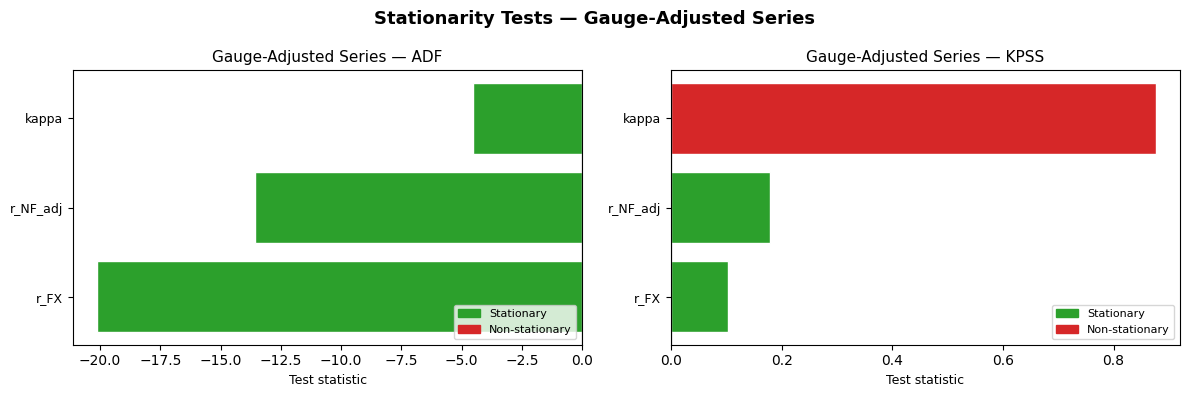

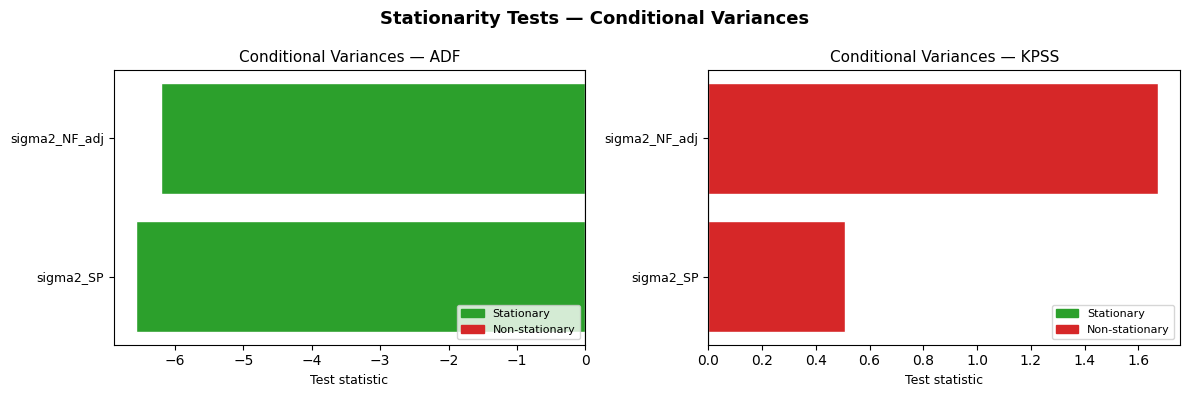

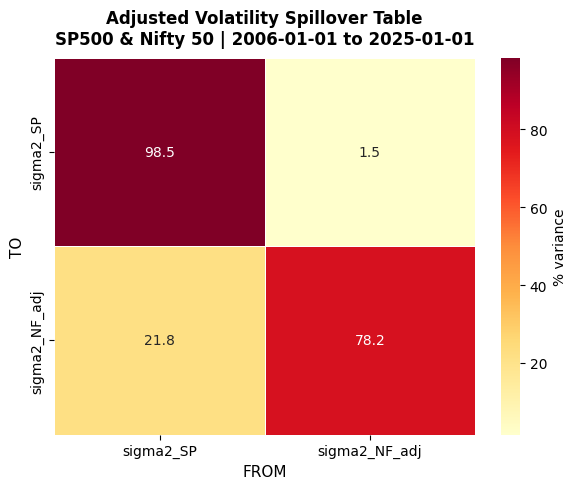

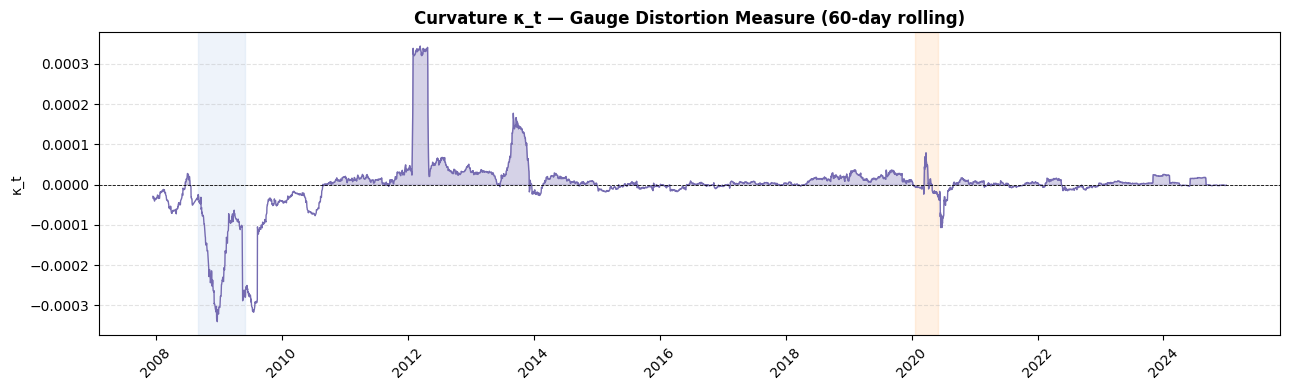

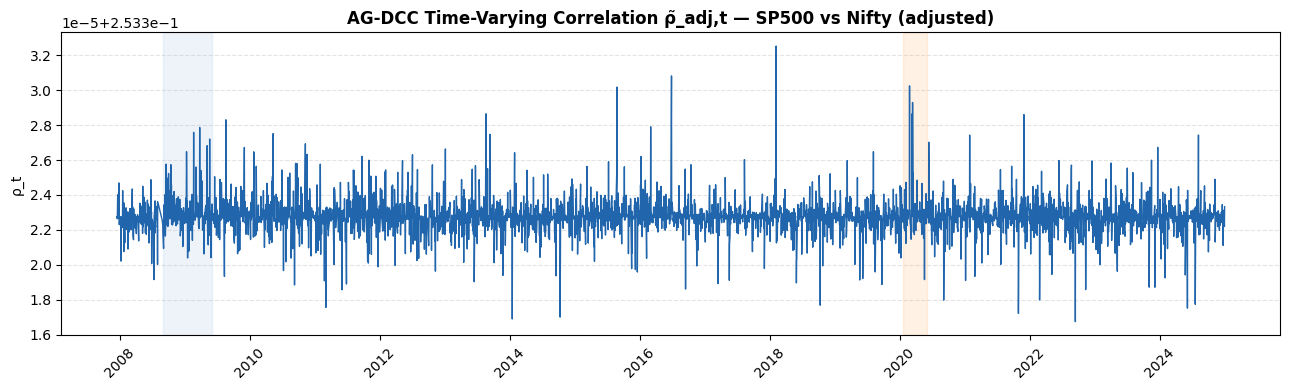

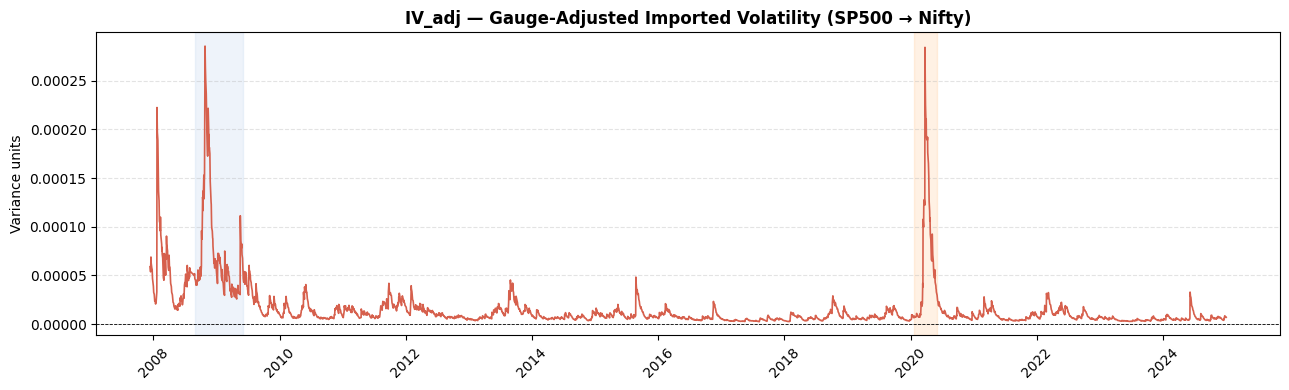

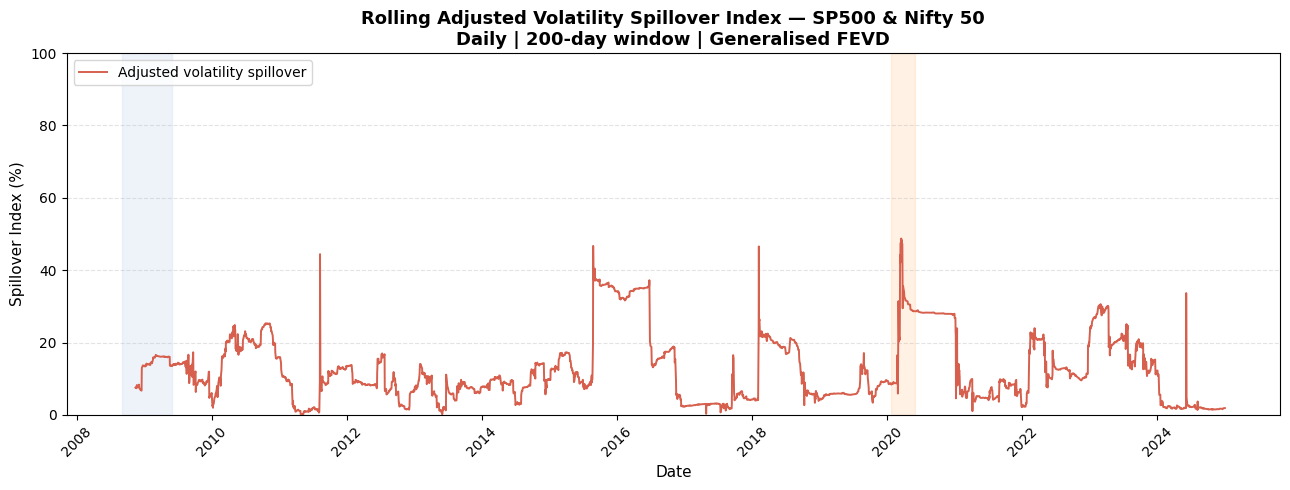


Done.



In [11]:
"""
Adjusted Volatility Spillover Pipeline
=======================================
Clean pipeline — gauge correction upstream, volatility spillover downstream.

Step 1 — Gauge adjustment on returns
         r_NF_adj = r_NF - r_FX
         κ_t      = σ²_FX,t + 2·Cov_t(r_NF, r_FX)   [60-day rolling]

Step 2 — GJR-GARCH(1,1,1) directly on r_SP and r_NF_adj
         → σ²_SP,t,  z_SP,t   (conditional variance + standardised residuals)
         → σ²_NF,t,  z_NF,t

Step 3 — VAR + GFEVD on [σ²_SP,t, σ²_NF_adj,t]
         → Adjusted volatility spillover table

Step 4 — AG-DCC on [z_SP,t, z_NF_adj,t]
         → ρ̃_adj,t

Step 5 — Imported volatility
         IV_adj,t = σ²_NF_adj,t · (ρ̃_adj,t)²

Step 6 — Rolling volatility spillover index
         Sliding window over [σ²_SP,t, σ²_NF_adj,t]

Step 7 — Curvature analysis
         κ_t persistence + IV_adj predictability

Dependencies
------------
pip install yfinance pandas numpy statsmodels matplotlib seaborn arch
"""

# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from scipy.optimize import minimize
from arch import arch_model
from matplotlib.patches import Patch

# ── Configuration ─────────────────────────────────────────────────────────────
START     = "2006-01-01"
END       = "2025-01-01"
VAR_ORDER = 2
H         = 10        # GFEVD forecast horizon
ROLL_WIN  = 200       # rolling spillover window
GK_ROLL   = 60        # curvature rolling window
SIG_LEVEL = 0.05

TICKERS = {
    "SP500"  : "^GSPC",
    "Nifty50": "^NSEI",
    "USDINR" : "INR=X",
}


# ══════════════════════════════════════════════════════════════════════════════
# 1. DATA
# ══════════════════════════════════════════════════════════════════════════════

def download_close(ticker: str, start: str, end: str) -> pd.Series:
    data = yf.download(ticker, start=start, end=end,
                       auto_adjust=True, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    close = data["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    return close.rename(ticker)


def build_returns(start: str, end: str) -> pd.DataFrame:
    """
    Download SP500, Nifty50, USD/INR.
    Return aligned DataFrame of daily log-returns: [r_SP, r_NF, r_FX].
    """
    closes = {name: download_close(tkr, start, end)
              for name, tkr in TICKERS.items()}
    df  = pd.DataFrame(closes).dropna()
    ret = np.log(df).diff().dropna()
    ret.columns = ["r_SP", "r_NF", "r_FX"]
    return ret


# ══════════════════════════════════════════════════════════════════════════════
# 2. STATIONARITY  (ADF + KPSS — matches raw DY format)
# ══════════════════════════════════════════════════════════════════════════════

def run_adf(series: pd.Series) -> dict:
    res = adfuller(series.dropna(), autolag="AIC", regression="c")
    return {
        "stat"      : res[0],
        "p_value"   : res[1],
        "lags"      : res[2],
        "cv_1pct"   : res[4]["1%"],
        "cv_5pct"   : res[4]["5%"],
        "cv_10pct"  : res[4]["10%"],
        "stationary": res[1] < SIG_LEVEL,
    }


def run_kpss(series: pd.Series) -> dict:
    stat, p_value, lags, crit = kpss(series.dropna(),
                                      regression="c", nlags="auto")
    return {
        "stat"      : stat,
        "p_value"   : p_value,
        "lags"      : lags,
        "cv_1pct"   : crit["1%"],
        "cv_5pct"   : crit["5%"],
        "cv_10pct"  : crit["10%"],
        "stationary": p_value >= SIG_LEVEL,
    }


def _verdict(adf_stat: bool, kpss_stat: bool) -> str:
    if adf_stat and kpss_stat:
        return "I(0) => OK"
    elif adf_stat and not kpss_stat:
        return "Trend-stationary? — check visually"
    elif not adf_stat and kpss_stat:
        return "Inconclusive — proceed with care"
    else:
        return "I(1) => DIFFERENCE before use"


def stationarity_report(df: pd.DataFrame, label: str) -> pd.DataFrame:
    SEP = "-" * 66
    print(f"\n{SEP}")
    print(f" Stationarity Tests — {label}")
    print(SEP)
    print(f" Significance level : {SIG_LEVEL*100:.0f}%")
    print(f" ADF H0 : unit root present (reject => stationary)")
    print(f" KPSS H0 : series is stationary (reject => non-stationary)")
    print(SEP)
    rows = []
    for col in df.columns:
        adf = run_adf(df[col])
        kp  = run_kpss(df[col])
        verdict = _verdict(adf["stationary"], kp["stationary"])
        print(f"\n Series : {col}")
        print(f" ADF stat = {adf['stat']:>9.4f} p = {adf['p_value']:.4f} "
              f"lags = {adf['lags']:>3} => "
              f"{'stationary' if adf['stationary'] else 'unit root'}")
        print(f" crit: 1% = {adf['cv_1pct']:>7.3f} "
              f"5% = {adf['cv_5pct']:>7.3f} 10% = {adf['cv_10pct']:>7.3f}")
        print(f" KPSS stat = {kp['stat']:>9.4f} p = {kp['p_value']:.4f} "
              f"lags = {kp['lags']:>3} => "
              f"{'stationary' if kp['stationary'] else 'non-stationary'}")
        print(f" crit: 1% = {kp['cv_1pct']:>7.3f} "
              f"5% = {kp['cv_5pct']:>7.3f} 10% = {kp['cv_10pct']:>7.3f}")
        print(f" Verdict : {verdict}")
        rows.append({
            "Series"         : col,
            "ADF stat"       : round(adf["stat"], 4),
            "ADF p-value"    : round(adf["p_value"], 4),
            "ADF stationary" : adf["stationary"],
            "KPSS stat"      : round(kp["stat"], 4),
            "KPSS p-value"   : round(kp["p_value"], 4),
            "KPSS stationary": kp["stationary"],
            "Verdict"        : verdict,
        })
    print(f"\n{SEP}\n")
    return pd.DataFrame(rows).set_index("Series")


def ensure_stationary(df: pd.DataFrame, summary: pd.DataFrame,
                      label: str) -> pd.DataFrame:
    needs_diff = [
        col for col in df.columns
        if col in summary.index
        and not summary.loc[col, "ADF stationary"]
        and not summary.loc[col, "KPSS stationary"]
    ]
    if not needs_diff:
        print(f" [{label}] All series pass stationarity — no differencing applied.\n")
        return df
    print(f" [{label}] First-differencing columns: {needs_diff}")
    df_out = df.copy()
    for col in needs_diff:
        df_out[col] = df[col].diff()
    df_out = df_out.dropna()
    for col in needs_diff:
        a2 = run_adf(df_out[col])
        k2 = run_kpss(df_out[col])
        ok = a2["stationary"] and k2["stationary"]
        print(f" {col} after diff: ADF p={a2['p_value']:.4f} "
              f"KPSS p={k2['p_value']:.4f} "
              f"[{'OK' if ok else 'STILL FAILING — inspect manually'}]")
    print()
    return df_out


# ══════════════════════════════════════════════════════════════════════════════
# 3. GAUGE ADJUSTMENT + CURVATURE
# ══════════════════════════════════════════════════════════════════════════════

def gauge_adjust(ret: pd.DataFrame) -> pd.DataFrame:
    """
    r_NF_adj = r_NF - r_FX
    κ_t      = σ²_FX,t + 2·Cov_t(r_NF, r_FX)   [GK_ROLL-day rolling]
    """
    ret = ret.copy()
    ret["r_NF_adj"] = ret["r_NF"] - ret["r_FX"]
    roll         = ret[["r_NF", "r_FX"]].rolling(GK_ROLL)
    sigma2_fx    = roll["r_FX"].var()
    cov_nf_fx    = roll.cov().unstack()["r_NF"]["r_FX"]
    ret["kappa"] = sigma2_fx + 2 * cov_nf_fx
    return ret.dropna()


# ══════════════════════════════════════════════════════════════════════════════
# 4. GJR-GARCH
# ══════════════════════════════════════════════════════════════════════════════

def fit_gjr_garch(series: pd.Series, label: str) -> tuple:
    """
    Fit GJR-GARCH(1,1,1) directly on a return series.
    Returns (conditional_variance, standardised_residuals).
    """
    print(f"  Fitting GJR-GARCH on {label} ...")
    scale = series.std()
    r     = (series / scale) * 100

    am  = arch_model(r, vol="Garch", p=1, o=1, q=1,
                     dist="normal", rescale=False)
    res = am.fit(disp="off", options={"maxiter": 500})

    cond_std  = (res.conditional_volatility / 100) * scale
    cond_var  = cond_std ** 2
    std_resid = series / cond_std

    print(f"   omega={res.params['omega']:.4e}  "
          f"alpha={res.params['alpha[1]']:.4f}  "
          f"gamma={res.params['gamma[1]']:.4f}  "
          f"beta={res.params['beta[1]']:.4f}")
    return cond_var, std_resid


# ══════════════════════════════════════════════════════════════════════════════
# 5. GENERALISED FEVD
# ══════════════════════════════════════════════════════════════════════════════

def generalised_fevd(results, H: int) -> np.ndarray:
    N     = results.neqs
    sigma = np.asarray(results.sigma_u, dtype=float)
    MA    = np.asarray(results.ma_rep(maxn=H), dtype=float)
    fevd  = np.zeros((N, N))
    for i in range(N):
        e_i   = np.zeros(N); e_i[i] = 1.0
        denom = sum(float(e_i @ MA[h] @ sigma @ MA[h].T @ e_i)
                    for h in range(H))
        for j in range(N):
            numer = sum(float(e_i @ MA[h] @ sigma[:, j])**2
                        for h in range(H))
            fevd[i, j] = numer / (sigma[j, j] * denom)
    fevd /= fevd.sum(axis=1, keepdims=True)
    return fevd


def spillover_index(fevd: np.ndarray) -> float:
    return 100.0 * (fevd.sum() - np.trace(fevd)) / fevd.sum()


def spillover_table(df: pd.DataFrame, var_order: int, H: int) -> tuple:
    results = VAR(df).fit(var_order, trend="c")
    fevd    = generalised_fevd(results, H)
    tbl     = pd.DataFrame(fevd * 100,
                            index=df.columns, columns=df.columns)
    return tbl, results


def print_spillover_table(tbl: pd.DataFrame, label: str):
    si  = spillover_index(tbl.values / 100)
    SEP = "-" * 56
    print(f"\n{SEP}")
    print(f" {label} Spillover Table (%)")
    print(SEP)
    print(tbl.round(2).to_string())
    print(f"\n Contribution TO Others:")
    for col in tbl.columns:
        print(f"  {col:>16} => {tbl[col].sum() - tbl.loc[col, col]:.2f}%")
    print(f"\n Contribution FROM Others:")
    for idx in tbl.index:
        print(f"  {idx:>16} <= {tbl.loc[idx].sum() - tbl.loc[idx, idx]:.2f}%")
    print(f"\n Total Spillover Index : {si:.2f}%")
    print(f"{SEP}\n")


# ══════════════════════════════════════════════════════════════════════════════
# 6. AG-DCC
# ══════════════════════════════════════════════════════════════════════════════

def ag_dcc(std_resid_df: pd.DataFrame, label: str) -> pd.Series:
    """
    Asymmetric Generalised DCC on two standardised residual series.
    Q_t = (1-a-b)*Q_bar + a*(u_{t-1} u_{t-1}') + n*(e_{t-1} e_{t-1}') + b*Q_{t-1}
    where e_t = min(u_t, 0).
    Returns ρ_t = R_t[0,1].
    """
    print(f"  Fitting AG-DCC on {label} standardised residuals ...")
    u     = std_resid_df.values.astype(float)
    T     = u.shape[0]
    Q_bar = np.cov(u.T)
    e     = np.minimum(u, 0)

    def dcc_filter(params):
        a, b, n = params
        Q   = Q_bar.copy()
        rho = np.zeros(T)
        for t in range(T):
            if t > 0:
                u_lag = u[t-1:t].T
                e_lag = e[t-1:t].T
                Q = ((1 - a - b) * Q_bar
                     + a * (u_lag @ u_lag.T)
                     + n * (e_lag @ e_lag.T)
                     + b * Q)
            diag   = np.sqrt(np.diag(Q))
            R      = Q / np.outer(diag, diag)
            rho[t] = R[0, 1]
        return rho

    def neg_loglik(params):
        a, b, n = params
        if a <= 0 or b <= 0 or n < 0 or a + b + n >= 1:
            return 1e10
        Q  = Q_bar.copy()
        ll = 0.0
        for t in range(T):
            if t > 0:
                u_lag = u[t-1:t].T
                e_lag = e[t-1:t].T
                Q = ((1 - a - b) * Q_bar
                     + a * (u_lag @ u_lag.T)
                     + n * (e_lag @ e_lag.T)
                     + b * Q)
            diag = np.sqrt(np.diag(Q))
            R    = Q / np.outer(diag, diag)
            sign, logdet = np.linalg.slogdet(R)
            if sign <= 0:
                return 1e10
            ll += logdet + float(u[t] @ np.linalg.solve(R, u[t]))
        return ll

    x0     = np.array([0.03, 0.94, 0.01])
    bounds = [(1e-6, 0.5), (1e-6, 0.999), (0, 0.3)]
    opt    = minimize(neg_loglik, x0, method="L-BFGS-B", bounds=bounds,
                      options={"maxiter": 200, "ftol": 1e-9})
    a_hat, b_hat, n_hat = opt.x
    print(f"   DCC a={a_hat:.4f}  b={b_hat:.4f}  n={n_hat:.4f}  "
          f"converged={opt.success}")

    rho = dcc_filter(opt.x)
    return pd.Series(rho, index=std_resid_df.index, name=f"rho_{label}")


# ══════════════════════════════════════════════════════════════════════════════
# 7. IMPORTED VOLATILITY
# ══════════════════════════════════════════════════════════════════════════════

def imported_volatility(sigma2_NF: pd.Series, rho: pd.Series) -> pd.Series:
    aligned = sigma2_NF.align(rho, join="inner")
    iv      = aligned[0] * aligned[1] ** 2
    iv.name = "IV_adj"
    return iv


# ══════════════════════════════════════════════════════════════════════════════
# 8. ROLLING VOLATILITY SPILLOVER
# ══════════════════════════════════════════════════════════════════════════════

def rolling_spillover(df: pd.DataFrame, var_order: int, H: int,
                      window: int) -> pd.Series:
    indices, values = [], []
    n     = len(df)
    total = n - window + 1
    for end_idx in range(window, n + 1):
        subset = df.iloc[end_idx - window: end_idx]
        try:
            res  = VAR(subset).fit(var_order, trend="c")
            fevd = generalised_fevd(res, H)
            si   = spillover_index(fevd)
        except Exception:
            si = np.nan
        indices.append(df.index[end_idx - 1])
        values.append(si)
        done = end_idx - window + 1
        if done % 500 == 0 or done == total:
            print(f"  ... {done}/{total} windows", end="\r", flush=True)
    print()
    return pd.Series(values, index=indices, name="Spillover_vol_adj")


# ══════════════════════════════════════════════════════════════════════════════
# 9. CURVATURE ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

def curvature_analysis(kappa: pd.Series, iv_adj: pd.Series):
    """
    8a. Persistence:    κ_t = φ0 + φ1·κ_{t-1} + ν_t
    8b. Predictability: IV_adj_{t+h} = α + β·κ_t + η_t  (h = 1, 5, 22)
    8c. Regime:         mean IV_adj — high vs low |κ_t|
    """
    SEP = "-" * 66
    print(f"\n{SEP}")
    print(f" Curvature Analysis")
    print(SEP)

    # 8a — AR(1) persistence of κ_t
    k_lag  = kappa.shift(1).dropna()
    k_curr = kappa.loc[k_lag.index]
    res_ar = OLS(k_curr, add_constant(k_lag)).fit(
        cov_type="HAC", cov_kwds={"maxlags": 5})
    print(f"\n [8a] κ_t persistence — AR(1)")
    print(f"  φ1 = {res_ar.params.iloc[1]:.4f}  "
          f"t = {res_ar.tvalues.iloc[1]:.3f}  "
          f"p = {res_ar.pvalues.iloc[1]:.4f}  "
          f"R² = {res_ar.rsquared:.4f}")

    # 8b — Predictability at h = 1, 5, 22
    print(f"\n [8b] Predictability : IV_adj_{{t+h}} ~ α + β·κ_t")
    for h in [1, 5, 22]:
        iv_fwd  = iv_adj.shift(-h)
        aligned = pd.concat([kappa, iv_fwd], axis=1).dropna()
        aligned.columns = ["kappa", "iv_fwd"]
        res_p   = OLS(aligned["iv_fwd"],
                      add_constant(aligned["kappa"])).fit(
                          cov_type="HAC", cov_kwds={"maxlags": h + 2})
        print(f"  h={h:>2}d : β={res_p.params.iloc[1]:.4f}  "
              f"t={res_p.tvalues.iloc[1]:.3f}  "
              f"p={res_p.pvalues.iloc[1]:.4f}  "
              f"R²={res_p.rsquared:.4f}")

    # 8c — Regime comparison
    median_k  = kappa.abs().median()
    high_mask = kappa.abs() > median_k
    hi_iv     = iv_adj[high_mask].mean()
    lo_iv     = iv_adj[~high_mask].mean()
    print(f"\n [8c] Regime : mean IV_adj")
    print(f"  High |κ| : {hi_iv:.6e}")
    print(f"  Low  |κ| : {lo_iv:.6e}")
    print(f"  Diff     : {hi_iv - lo_iv:.6e}")
    print(f"\n{SEP}\n")


# ══════════════════════════════════════════════════════════════════════════════
# 10. PLOTS
# ══════════════════════════════════════════════════════════════════════════════

CRISIS = [
    ("2008-09-01", "2009-06-01", "#aec7e8", "GFC"),
    ("2020-01-20", "2020-06-01", "#ffbb78", "COVID-19"),
]


def _shade_crises(ax):
    for s, e, col, lbl in CRISIS:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                   alpha=0.2, color=col, label=lbl)


def _format_xaxis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.xticks(rotation=45)


def plot_spillover_heatmap(tbl: pd.DataFrame, title: str, fname: str):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(tbl, annot=True, fmt=".1f", cmap="YlOrRd",
                linewidths=0.5, ax=ax, cbar_kws={"label": "% variance"})
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("FROM", fontsize=11)
    ax.set_ylabel("TO", fontsize=11)
    plt.tight_layout()
    fig.savefig(fname, dpi=150)
    print(f"  Saved {fname}")
    return fig


def plot_stationarity_bars(summary: pd.DataFrame, label: str, fname: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Stationarity Tests — {label}",
                 fontsize=13, fontweight="bold")
    specs = [
        (axes[0], "ADF stat",  "ADF stationary",  f"{label} — ADF"),
        (axes[1], "KPSS stat", "KPSS stationary", f"{label} — KPSS"),
    ]
    for ax, metric, flag, title in specs:
        vals   = summary[metric]
        colors = ["#2ca02c" if v else "#d62728" for v in summary[flag]]
        ax.barh(vals.index, vals.values, color=colors, edgecolor="white")
        ax.set_title(title, fontsize=11)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_xlabel("Test statistic", fontsize=9)
        ax.tick_params(axis="y", labelsize=9)
        ax.legend(handles=[
            Patch(color="#2ca02c", label="Stationary"),
            Patch(color="#d62728", label="Non-stationary"),
        ], fontsize=8, loc="lower right")
    plt.tight_layout()
    fig.savefig(fname, dpi=150)
    print(f"  Saved {fname}")


def plot_kappa(kappa: pd.Series):
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(kappa.index, kappa.values, color="#756bb1", linewidth=1.0)
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax.fill_between(kappa.index, kappa.values, 0,
                    where=kappa.values > 0, alpha=0.3, color="#756bb1")
    ax.set_title(f"Curvature κ_t — Gauge Distortion Measure "
                 f"({GK_ROLL}-day rolling)",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("κ_t", fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    _shade_crises(ax)
    _format_xaxis(ax)
    plt.tight_layout()
    fig.savefig("kappa_curvature.png", dpi=150)
    print("  Saved kappa_curvature.png")


def plot_rho(rho_adj: pd.Series):
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(rho_adj.index, rho_adj.values, color="#2166ac", linewidth=1.0)
    ax.set_title(
        "AG-DCC Time-Varying Correlation ρ̃_adj,t — SP500 vs Nifty (adjusted)",
        fontsize=12, fontweight="bold")
    ax.set_ylabel("ρ_t", fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    _shade_crises(ax)
    _format_xaxis(ax)
    plt.tight_layout()
    fig.savefig("dcc_rho_adj.png", dpi=150)
    print("  Saved dcc_rho_adj.png")


def plot_iv(iv_adj: pd.Series):
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(iv_adj.index, iv_adj.values, color="#d6604d", linewidth=1.2)
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax.set_title(
        "IV_adj — Gauge-Adjusted Imported Volatility (SP500 → Nifty)",
        fontsize=12, fontweight="bold")
    ax.set_ylabel("Variance units", fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    _shade_crises(ax)
    _format_xaxis(ax)
    plt.tight_layout()
    fig.savefig("iv_adj.png", dpi=150)
    print("  Saved iv_adj.png")


def plot_rolling(roll_adj: pd.Series):
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(roll_adj.index, roll_adj.values,
            color="#d6604d", linewidth=1.4,
            label="Adjusted volatility spillover")
    ax.set_title(
        f"Rolling Adjusted Volatility Spillover Index — SP500 & Nifty 50\n"
        f"Daily | {ROLL_WIN}-day window | Generalised FEVD",
        fontsize=13, fontweight="bold"
    )
    ax.set_ylabel("Spillover Index (%)", fontsize=11)
    ax.set_xlabel("Date", fontsize=11)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=10, loc="upper left")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    _shade_crises(ax)
    _format_xaxis(ax)
    plt.tight_layout()
    fig.savefig("spillover_vol_adj_rolling.png", dpi=150)
    print("  Saved spillover_vol_adj_rolling.png")


# ══════════════════════════════════════════════════════════════════════════════
# 11. MAIN
# ══════════════════════════════════════════════════════════════════════════════

def main():
    print("=" * 66)
    print("  Adjusted Volatility Spillover Pipeline")
    print("  S&P 500 x Nifty 50 | Gauge-Corrected | GJR-GARCH + AG-DCC")
    print(f"  Period : {START} to {END}")
    print("=" * 66)

    # ── 1. Download ───────────────────────────────────────────────────────────
    print("\n[1/7] Downloading returns (SP500, Nifty50, USD/INR) ...")
    ret = build_returns(START, END)
    print(f"  Returns : {ret.shape}  "
          f"({ret.index[0].date()} to {ret.index[-1].date()})")

    # ── 2. Gauge adjustment + κ_t ─────────────────────────────────────────────
    print("\n[2/7] Gauge adjustment — r_NF_adj = r_NF - r_FX ...")
    ret = gauge_adjust(ret)
    print(f"  r_NF_adj : mean={ret['r_NF_adj'].mean():.6f}  "
          f"std={ret['r_NF_adj'].std():.6f}")
    print(f"  κ_t      : mean={ret['kappa'].mean():.6e}  "
          f"std={ret['kappa'].std():.6e}")

    # ── 2b. Stationarity on new series ────────────────────────────────────────
    print("\n[2b/7] Stationarity tests — r_FX, r_NF_adj, κ_t ...")
    stat_summary = stationarity_report(
        ret[["r_FX", "r_NF_adj", "kappa"]], "Gauge-Adjusted Series")
    ret = ensure_stationary(ret, stat_summary, "Gauge-Adjusted")
    plot_stationarity_bars(stat_summary, "Gauge-Adjusted Series",
                           "stationarity_adj.png")

    # ── 3. GJR-GARCH directly on returns ─────────────────────────────────────
    print("\n[3/7] GJR-GARCH(1,1,1) on r_SP and r_NF_adj ...")
    sigma2_SP, z_SP = fit_gjr_garch(ret["r_SP"],     "SP500")
    sigma2_NF, z_NF = fit_gjr_garch(ret["r_NF_adj"], "Nifty (adj)")

    # ── 4. Volatility spillover table ─────────────────────────────────────────
    print("\n[4/7] VAR + GFEVD on [σ²_SP, σ²_NF_adj] ...")
    vol_data = pd.DataFrame({
        "sigma2_SP"    : sigma2_SP,
        "sigma2_NF_adj": sigma2_NF,
    }).dropna()

    vol_stat_summary = stationarity_report(vol_data, "Conditional Variances")
    vol_data = ensure_stationary(vol_data, vol_stat_summary,
                                 "Conditional Variances")
    plot_stationarity_bars(vol_stat_summary, "Conditional Variances",
                           "stationarity_vol.png")

    vol_tbl, _ = spillover_table(vol_data, VAR_ORDER, H)
    print_spillover_table(vol_tbl, "Adjusted Volatility")
    plot_spillover_heatmap(
        vol_tbl,
        f"Adjusted Volatility Spillover Table\n"
        f"SP500 & Nifty 50 | {START} to {END}",
        "spillover_table_vol_adj.png"
    )

    # ── 5. AG-DCC ─────────────────────────────────────────────────────────────
    print("\n[5/7] AG-DCC on [z_SP, z_NF_adj] ...")
    std_df  = pd.DataFrame({"z_SP": z_SP, "z_NF_adj": z_NF}).dropna()
    rho_adj = ag_dcc(std_df, label="adj")

    # ── 6. Imported volatility ────────────────────────────────────────────────
    print("\n[6/7] Imported volatility — IV_adj,t = σ²_NF_adj,t · ρ̃²_adj,t ...")
    iv_adj = imported_volatility(sigma2_NF, rho_adj)
    print(f"  IV_adj : mean={iv_adj.mean():.6e}  max={iv_adj.max():.6e}  "
          f"positive={100*(iv_adj > 0).mean():.1f}% of days")

    # ── 7. Rolling volatility spillover ───────────────────────────────────────
    print(f"\n[7/7] Rolling volatility spillover (window={ROLL_WIN} days) ...")
    roll_adj = rolling_spillover(vol_data, VAR_ORDER, H, ROLL_WIN)

    # ── Granger Causality ─────────────────────────────────────────────────────
    from statsmodels.tsa.stattools import grangercausalitytests

    print("\n Granger Causality Tests — Conditional Variances")
    print("-" * 56)

    print("\n H0: sigma2_SP does NOT Granger-cause sigma2_NF_adj")
    gc1 = grangercausalitytests(
        vol_data[["sigma2_NF_adj", "sigma2_SP"]], maxlag=VAR_ORDER, verbose=False)
    for lag, res in gc1.items():
        f_stat = res[0]["ssr_ftest"][0]
        p_val  = res[0]["ssr_ftest"][1]
        print(f"  lag={lag} : F={f_stat:.4f}  p={p_val:.4f}  "
              f"{'reject H0' if p_val < SIG_LEVEL else 'fail to reject'}")

    print("\n H0: sigma2_NF_adj does NOT Granger-cause sigma2_SP")
    gc2 = grangercausalitytests(
        vol_data[["sigma2_SP", "sigma2_NF_adj"]], maxlag=VAR_ORDER, verbose=False)
    for lag, res in gc2.items():
        f_stat = res[0]["ssr_ftest"][0]
        p_val  = res[0]["ssr_ftest"][1]
        print(f"  lag={lag} : F={f_stat:.4f}  p={p_val:.4f}  ")

    # ── Curvature analysis ────────────────────────────────────────────────────
    kappa_al, iv_al = ret["kappa"].align(iv_adj, join="inner")
    curvature_analysis(kappa_al, iv_al)

    # ── Plots ─────────────────────────────────────────────────────────────────
    print("Saving plots ...")
    plot_kappa(ret["kappa"])
    plot_rho(rho_adj)
    plot_iv(iv_adj)
    plot_rolling(roll_adj)

    # ── Save CSVs ─────────────────────────────────────────────────────────────
    pd.DataFrame({
        "r_SP"    : ret["r_SP"],
        "r_NF"    : ret["r_NF"],
        "r_FX"    : ret["r_FX"],
        "r_NF_adj": ret["r_NF_adj"],
        "kappa"   : ret["kappa"],
    }).to_csv("gauge_series.csv")

    pd.DataFrame({
        "sigma2_SP"    : sigma2_SP,
        "sigma2_NF_adj": sigma2_NF,
        "rho_adj"      : rho_adj,
        "IV_adj"       : iv_adj,
    }).to_csv("iv_results.csv")
    print("  Saved gauge_series.csv and iv_results.csv")

    # ── Summary ───────────────────────────────────────────────────────────────
    print("\n" + "=" * 66)
    print("  SUMMARY")
    print("=" * 66)
    print(f"\n  Full-sample adjusted volatility spillover (US→India):")
    print(f"    sigma2_NF_adj <= sigma2_SP : "
          f"{vol_tbl.loc['sigma2_NF_adj', 'sigma2_SP']:.2f}%")
    print(f"    Total Spillover Index      : "
          f"{spillover_index(vol_tbl.values / 100):.2f}%")
    print(f"\n  Imported volatility IV_adj:")
    print(f"    mean = {iv_adj.mean():.4e}  max = {iv_adj.max():.4e}")
    print(f"\n  Rolling volatility spillover ({ROLL_WIN}-day):")
    v = roll_adj.dropna()
    print(f"    mean={v.mean():.1f}%  min={v.min():.1f}%  "
          f"max={v.max():.1f}%  std={v.std():.1f}%")
    print("\n  Output files:")
    for f in ["gauge_series.csv", "iv_results.csv",
              "stationarity_adj.png", "stationarity_vol.png",
              "spillover_table_vol_adj.png",
              "kappa_curvature.png", "dcc_rho_adj.png",
              "iv_adj.png", "spillover_vol_adj_rolling.png"]:
        print(f"    {f}")

    plt.show()
    print("\nDone.\n")

if __name__ == "__main__":
    main()
